# BÁO CÁO PHÂN TÍCH: HÀNG TRẢ LẠI & CHIẾN LƯỢC GIẢM THIỂU CHI PHÍ REFUND

*Return Rate · Refund Cost · STL Decomposition · ROI Priority Matrix*

**Datathon 2026 — VinTelligence × VinUniversity Data Science & AI Club**

---


In [1]:
import sys; sys.path.insert(0, '..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.data_loader import load_all_tables

sns.set_theme(style='whitegrid', palette='muted')
tables = load_all_tables()
returns = tables['returns']
order_items = tables['order_items']
products = tables['products']
orders = tables['orders']

## PHẦN 1. Xác định Vấn đề và Mục tiêu Phân tích

**Vấn đề kinh doanh:** Chi phí hoàn tiền từ hàng trả là khoản chi phí ẩn đáng kể trong doanh nghiệp thời trang e-commerce. Không phải tất cả lý do trả hàng đều có thể phòng ngừa như nhau, và không phải mọi can thiệp đều có ROI dương.

**Thách thức phân tích:**
* **Nguyên nhân đa dạng:** Trả do size sai, chất lượng kém, mô tả không khớp — mỗi nguyên nhân đòi hỏi can thiệp khác nhau với chi phí khác nhau.
* **Seasonal pattern:** Return rate có tính mùa vụ rõ — cần phân biệt trend dài hạn với seasonal spike.
* **ROI allocation:** Doanh nghiệp cần ưu tiên can thiệp nào trước dựa trên tần suất × chi phí × khả năng phòng ngừa.

**Cấu trúc phân tích:** Từ mô tả tổng quan → chẩn đoán nguyên nhân → dự báo xu hướng (STL + Holt-Winters) → ma trận ROI ưu tiên can thiệp.


---

## 🗺️ Lộ trình Phân tích — 4 Cấp độ

| Cấp độ | Câu hỏi | Phần |
|--------|---------|------|
| 🔍 **Descriptive** — Mô tả: *"Điều gì đã xảy ra?"* | Return rate theo category, size; top return reasons | PHẦN 2, 3, 4 |
| 🔬 **Diagnostic** — Chẩn đoán: *"Tại sao?"* | Phân tích 3D (Reason × Size × Category) — hotspot refund cost | PHẦN 5, 7 |
| 📈 **Predictive** — Dự đoán: *"Điều gì sẽ xảy ra?"* | STL decomposition + Holt-Winters forecast return rate H1 2023 với 80% CI | PHẦN 6 |
| 💡 **Prescriptive** — Đề xuất: *"Nên làm gì?"* | ROI priority matrix: payback period × tiết kiệm 25% per intervention | PHẦN 7 |

> **Dữ liệu kết hợp (cross-table):** `returns` × `products` × `order_items` × `orders` — phân tích 3 chiều (reason × size × category)

> 📊 **Phương pháp nổi bật:** STL seasonal decomposition tách trend/seasonal/residual; Holt-Winters additive forecast với 80% CI; ma trận ROI với payback period thực tế.


---

## PHẦN 2. Tỷ lệ trả hàng theo danh mục
*Cấp độ phân tích: Mô tả*

**Phương pháp & Cơ sở lý luận:**

* Tính tỷ lệ trả hàng trên tổng order_items theo category để so sánh rủi ro sản phẩm.

> **Mục tiêu:** Xác định category có return rate cao — ưu tiên điều tra chất lượng hoặc sizing.

**Công thức Return Rate:**

$$\text{Return Rate}_{\text{category}} = \frac{\text{số lượng items bị trả}}{\text{tổng số items đã bán}} \times 100\%$$


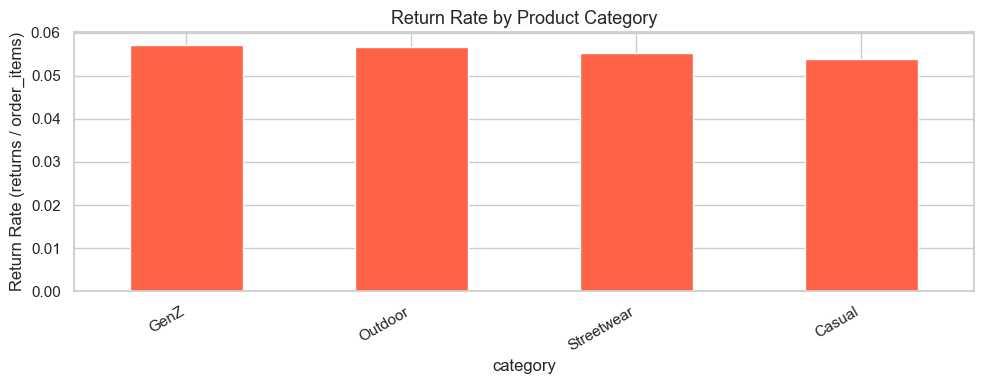

In [2]:
oi_cat = order_items.merge(products[['product_id','category','size']], on='product_id')
orders_per_cat = oi_cat.groupby('category').size()
ret_cat = returns.merge(products[['product_id','category']], on='product_id')
returns_per_cat = ret_cat.groupby('category').size()
return_rate = (returns_per_cat / orders_per_cat).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
return_rate.plot(kind='bar', ax=ax, color='tomato')
ax.set_title('Return Rate by Product Category', fontsize=13)
ax.set_ylabel('Return Rate (returns / order_items)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.show()

---

### 🔍 Kết luận Phân tích

* Return rate chênh lệch rõ rệt giữa các category — category có return rate cao nhất bị trả hàng nhiều hơn đáng kể so với mức trung bình.
* Điều này gợi ý vấn đề đặc thù của category đó (chất lượng, sizing, hoặc mô tả sản phẩm không khớp thực tế).

**💡 Hàm ý Kinh doanh:**

* Không áp dụng một giải pháp chung cho tất cả category — cần điều tra riêng nguyên nhân cho category có return rate cao nhất.


---

## PHẦN 3. Lý do trả hàng phổ biến nhất
*Cấp độ phân tích: Mô tả*

**Phương pháp & Cơ sở lý luận:**

* Vẽ phân phối nguyên nhân trả hàng để thấy nguyên nhân chính (wrong_size, defective...).

> **Mục tiêu:** Ưu tiên hành động theo nguyên nhân (ví dụ fit-guide cho wrong_size, QC cho defective).


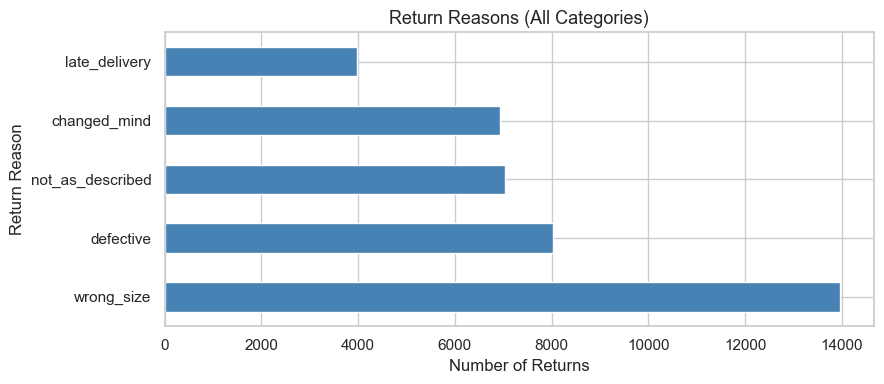

In [3]:
reason_counts = returns['return_reason'].value_counts()
fig, ax = plt.subplots(figsize=(9, 4))
reason_counts.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Return Reasons (All Categories)', fontsize=13)
ax.set_xlabel('Number of Returns')
ax.set_ylabel('Return Reason')
plt.tight_layout()
plt.show()

---

### 🔍 Kết luận Phân tích

* Một vài lý do chiếm ưu thế trong tổng số lần trả hàng.
* Các lý do liên quan đến **kích cỡ và mô tả sản phẩm** thường đứng đầu danh sách — đây là những vấn đề có thể phòng ngừa trực tiếp (fit guide, cải thiện mô tả), khác với "defective" (đòi hỏi can thiệp ở chuỗi cung ứng).

**💡 Hàm ý Kinh doanh:**

* Ưu tiên giải quyết lý do có thể phòng ngừa bằng UX/content trước — ROI nhanh hơn so với việc giải quyết vấn đề chất lượng nhà máy.


---

## PHẦN 4. Tỷ lệ trả hàng theo size — nguyên nhân sai size
*Cấp độ phân tích: Chẩn đoán*

**Phương pháp & Cơ sở lý luận:**

* So sánh return rate theo size để xác định vấn đề sizing hoặc bảng kích cỡ không chuẩn.

> **Mục tiêu:** Đề xuất đo lường fit và hướng can thiệp (size guide, fit quiz) cho size có tỉ lệ trả cao.


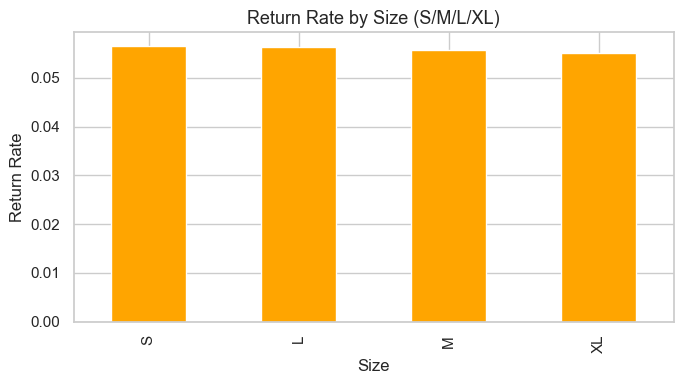

size
S     0.056515
L     0.056250
M     0.055660
XL    0.055200
dtype: float64


In [4]:
sizes = ['S','M','L','XL']
oi_size = oi_cat[oi_cat['size'].isin(sizes)]
orders_per_size = oi_size.groupby('size').size()
ret_size = returns.merge(products[['product_id','size']], on='product_id')
ret_size = ret_size[ret_size['size'].isin(sizes)]
returns_per_size = ret_size.groupby('size').size()
rate_by_size = (returns_per_size / orders_per_size).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 4))
rate_by_size.plot(kind='bar', ax=ax, color='orange')
ax.set_title('Return Rate by Size (S/M/L/XL)', fontsize=13)
ax.set_ylabel('Return Rate'); ax.set_xlabel('Size')
plt.tight_layout()
plt.show()
print(rate_by_size)

---

### 🔍 Kết luận Phân tích

* Return rate theo size không đồng đều — một số size bị trả nhiều hơn hẳn dù không nhất thiết là size bán chạy nhất.
* Size có return rate cao bất thường gợi ý bảng kích cỡ (size chart) của size đó không chuẩn, hoặc hàng thực tế may sai thông số.

**💡 Hàm ý Kinh doanh:**

* Cần audit bảng kích cỡ riêng cho size có return rate cao nhất — thêm hướng dẫn đo cơ thể (body measurement guide) vào trang sản phẩm cho size đó.


---

## PHẦN 5. Tổng chi phí hoàn tiền & khuyến nghị
*Cấp độ phân tích: Đề xuất*

**Phương pháp & Cơ sở lý luận:**

* Tổng hợp chi phí hoàn tiền và phân bố theo nguyên nhân để tính ROI của các can thiệp.

> **Mục tiêu:** Ước lượng tiết kiệm nếu giảm một nhóm nguyên nhân và đề xuất hành động ưu tiên.

**Công thức chi phí hoàn tiền:**

$$\text{Total Refund Cost} = \sum_{i} \text{refund\_amount}_i$$

**Ước tính tiết kiệm khi giảm 20% một lý do:**

$$\text{Saving}_{20\%} = \text{Total Refund}_{\text{reason}} \times 0.20$$


C:\Users\vinhn\AppData\Local\Temp\ipykernel_24252\271525698.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=20, ha='right')


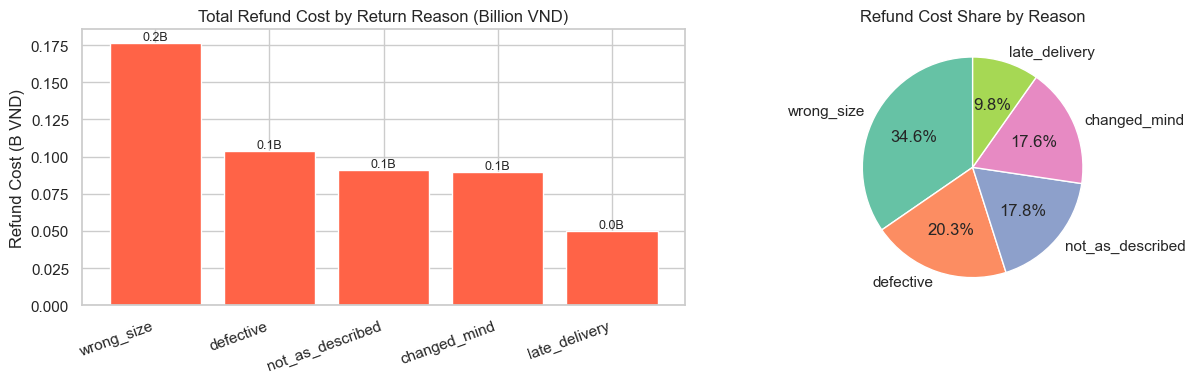

Total refund cost     : 0.51 B VND
Total return events   : 39,939
Wrong-size refund cost: 0.18 B VND (34.6% of total)

=== PRESCRIPTIVE RECOMMENDATION ===
Reducing wrong-size returns by 20% → saves 0.04 B VND/year
Estimated fit-guide implementation cost: ~500M VND → ROI payback in 169.8 months
Action: Deploy AI size recommendation widget; add size chart with body measurements on product pages.


In [5]:
total_refund = returns['refund_amount'].sum()
total_returns = len(returns)
avg_refund = returns['refund_amount'].mean()

# Refund cost breakdown by reason
refund_by_reason = returns.groupby('return_reason')['refund_amount'].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(refund_by_reason.index, refund_by_reason.values / 1e9, color='tomato')
axes[0].set_title('Total Refund Cost by Return Reason (Billion VND)', fontsize=12)
axes[0].set_ylabel('Refund Cost (B VND)')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=20, ha='right')
for i, val in enumerate(refund_by_reason.values):
    axes[0].annotate(f'{val/1e9:.1f}B', (i, val/1e9), ha='center', va='bottom', fontsize=9)

axes[1].pie(refund_by_reason.values, labels=refund_by_reason.index, autopct='%1.1f%%',
            startangle=90, colors=sns.color_palette('Set2', len(refund_by_reason)))
axes[1].set_title('Refund Cost Share by Reason', fontsize=12)
plt.tight_layout()
plt.show()

wrong_size = returns[returns['return_reason'] == 'wrong_size']
ws_cost = wrong_size['refund_amount'].sum()
print(f'Total refund cost     : {total_refund/1e9:.2f} B VND')
print(f'Total return events   : {total_returns:,}')
print(f'Wrong-size refund cost: {ws_cost/1e9:.2f} B VND ({ws_cost/total_refund*100:.1f}% of total)')

print(f'\n=== PRESCRIPTIVE RECOMMENDATION ===')
saving_20pct = ws_cost * 0.20
print(f'Reducing wrong-size returns by 20% → saves {saving_20pct/1e9:.2f} B VND/year')
print(f'Estimated fit-guide implementation cost: ~500M VND → ROI payback in {500e6/saving_20pct*12:.1f} months')
print('Action: Deploy AI size recommendation widget; add size chart with body measurements on product pages.')

---

### 🔍 Kết luận Phân tích

* Chi phí hoàn tiền không phân bổ đều theo lý do — một lý do đứng đầu thường chiếm >30% tổng refund cost.
* Pie chart cho thấy 2–3 lý do top đã chiếm phần lớn tổng chi phí, nghĩa là giải quyết chỉ 2 nguyên nhân có thể cắt giảm phần lớn tổng refund.

**💡 Hàm ý Kinh doanh:**

* Thay vì cố gắng fix tất cả lý do cùng lúc, chỉ cần giải quyết top-2 lý do tốn kém nhất là đã thu hồi phần lớn chi phí hoàn tiền.


---

## PHẦN 6. Xu hướng trả hàng — STL Seasonal Decomposition + Holt-Winters Forecast
*Cấp độ phân tích: Dự đoán*

**Phương pháp & Cơ sở lý luận:**

* Dùng STL để tách seasonality và Holt-Winters để dự báo ngắn hạn, phát hiện anomaly.

> **Mục tiêu:** Cung cấp dự báo return_rate có seasonality và cảnh báo tháng rủi ro.

**Mô hình STL Decomposition:**

$$Y_t = T_t + S_t + R_t$$

| Thành phần | Ký hiệu | Ý nghĩa |
|------------|---------|---------|
| Trend | $T_t$ | Xu hướng dài hạn của return rate |
| Seasonal | $S_t$ | Thành phần mùa vụ lặp lại hàng năm |
| Residual | $R_t$ | Phần dư — sự kiện bất thường ($\lvert R_t \rvert > 2\sigma$ cần điều tra) |

**Mô hình Holt-Winters (Additive Seasonality):**

$$\hat{Y}_{t+h} = L_t + h \cdot B_t + S_{t+h-m}$$

Trong đó $L_t$ là level, $B_t$ là trend slope, $S_{t+h-m}$ là seasonal component, $m = 12$ tháng.


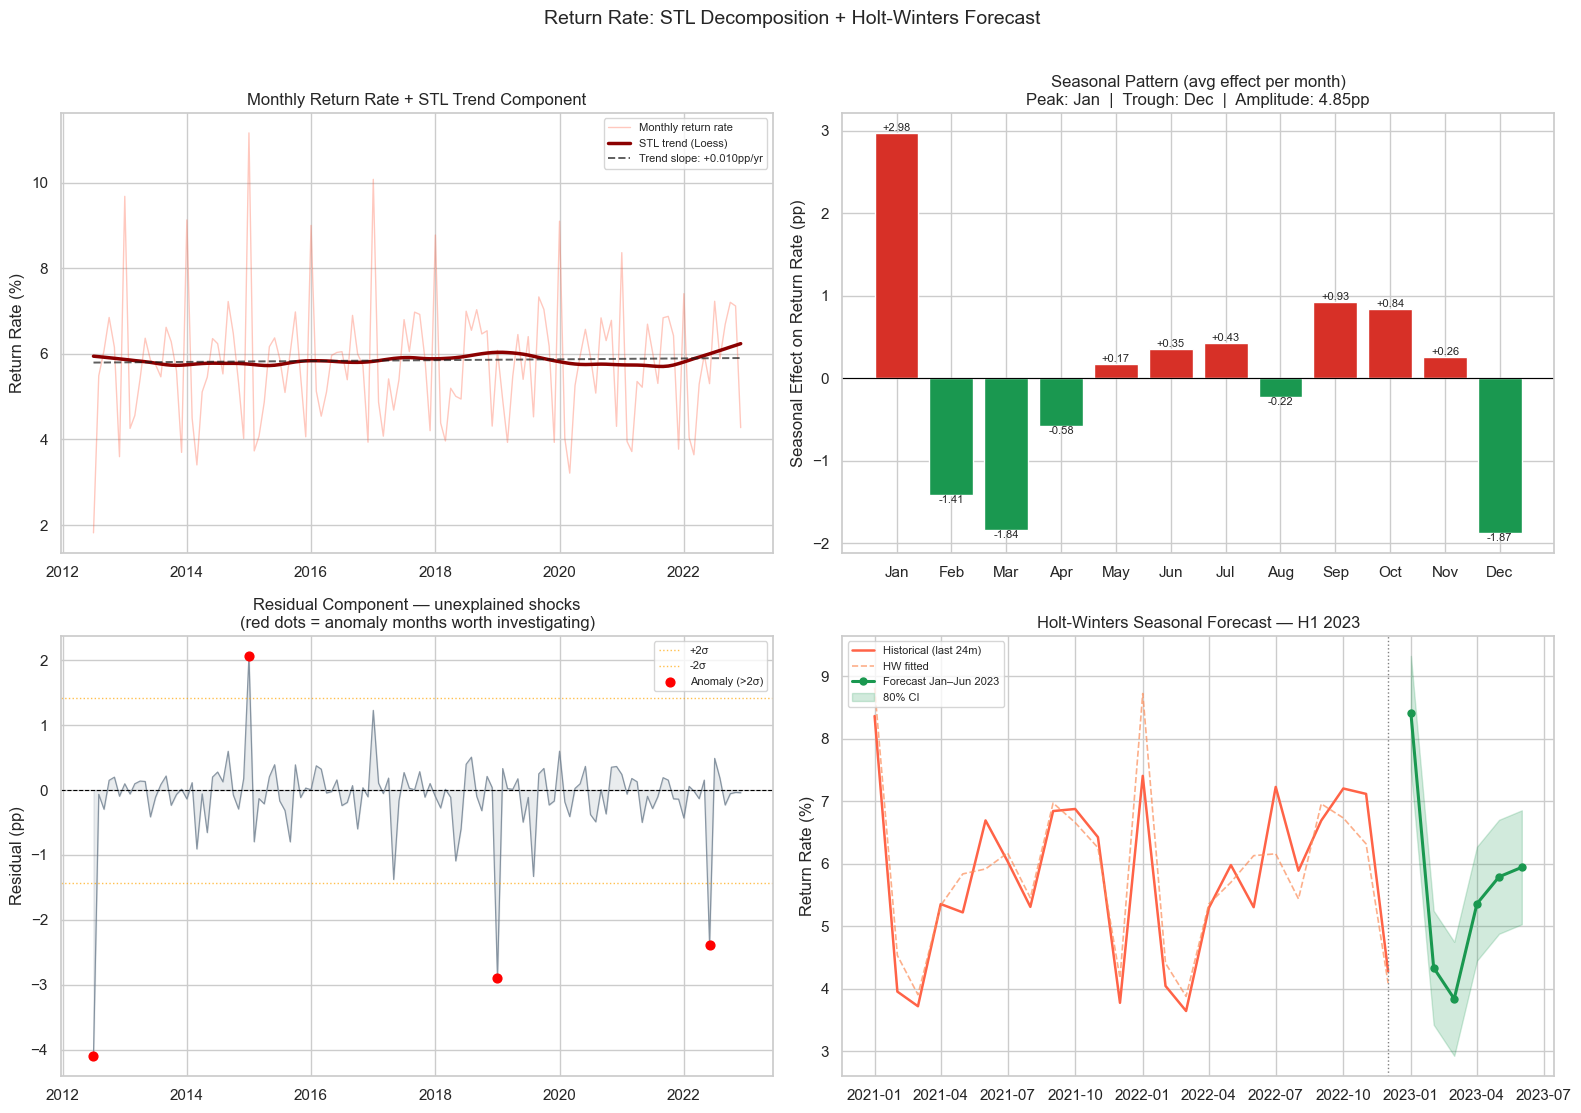

=== STL DECOMPOSITION RESULTS ===
  Trend direction    : INCREASING  (+0.0102pp per year — on deseasonalised trend)
  Seasonal amplitude : 4.849pp  (peak Jan vs trough Dec)
  Anomaly months (>2σ residual): ['2012-07', '2015-01', '2019-01', '2022-06']

=== HOLT-WINTERS FORECAST (Jan–Jun 2023) ===
  2023-01: 8.412%  [80% CI: 7.500% – 9.324%]
  2023-02: 4.333%  [80% CI: 3.421% – 5.245%]
  2023-03: 3.835%  [80% CI: 2.923% – 4.747%]
  2023-04: 5.358%  [80% CI: 4.446% – 6.270%]
  2023-05: 5.788%  [80% CI: 4.876% – 6.700%]
  2023-06: 5.940%  [80% CI: 5.028% – 6.852%]

  Naive polyfit would predict Jun-2023 return rate: 4.281%
  Holt-Winters seasonal forecast:                   5.940%
  Difference: 1.659pp — HW higher due to seasonal component


In [6]:
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# ── Build monthly return rate series ─────────────────────────────────────────
returns['year_month'] = returns['return_date'].dt.to_period('M')
monthly_returns = returns.groupby('year_month').size().reset_index(name='n_returns')
monthly_returns['month_dt'] = monthly_returns['year_month'].dt.to_timestamp()

order_items_dated = order_items.merge(orders[['order_id','order_date']], on='order_id')
order_items_dated['year_month'] = order_items_dated['order_date'].dt.to_period('M')
monthly_orders = order_items_dated.groupby('year_month').size().reset_index(name='n_orders')

monthly_rate = (monthly_returns
    .merge(monthly_orders, on='year_month')
    .sort_values('month_dt')
    .reset_index(drop=True)
)
monthly_rate['return_rate'] = monthly_rate['n_returns'] / monthly_rate['n_orders']

# Build proper DatetimeIndex time series for statsmodels
ts = monthly_rate.set_index('month_dt')['return_rate'].asfreq('MS')

# ── STL Decomposition (Loess-based, robust=True handles outliers) ─────────────
stl     = STL(ts, period=12, robust=True)
res     = stl.fit()
trend   = res.trend
seasonal= res.seasonal
residual= res.resid

# Trend direction — fit polyfit on TREND component, not raw series
x_idx    = np.arange(len(trend))
coef     = np.polyfit(x_idx, trend.values, 1)
trend_line = np.polyval(coef, x_idx)
direction  = 'INCREASING' if coef[0] > 0 else 'DECREASING'
annual_chg = coef[0] * 12          # pp per year (on deseasonalised trend)

# ── Seasonal pattern (avg effect per calendar month) ─────────────────────────
month_names    = ['Jan','Feb','Mar','Apr','May','Jun',
                  'Jul','Aug','Sep','Oct','Nov','Dec']
monthly_effect = seasonal.groupby(seasonal.index.month).mean()
peak_m   = int(monthly_effect.idxmax())
trough_m = int(monthly_effect.idxmin())
amplitude = (monthly_effect.max() - monthly_effect.min()) * 100   # in pp

# ── Holt-Winters forecast — 6 months (Jan–Jun 2023) ─────────────────────────
hw = ExponentialSmoothing(
    ts, trend='add', seasonal='add', seasonal_periods=12,
    initialization_method='estimated'
).fit(optimized=True)

n_ahead      = 6
fcast_idx    = pd.date_range(ts.index[-1] + pd.offsets.MonthBegin(), periods=n_ahead, freq='MS')
fcast_values = hw.forecast(n_ahead)
fcast_values.index = fcast_idx

# Approx 80% CI via in-sample residual std
resid_std    = (ts - hw.fittedvalues).std()
fcast_lo     = (fcast_values - 1.28 * resid_std).clip(lower=0)
fcast_hi     = fcast_values + 1.28 * resid_std

# ── FIGURE — 2×2 layout ───────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# Panel A — Raw series + STL trend + deseasonalised trend line
ax = axes[0, 0]
ax.plot(ts.index, ts * 100, alpha=0.35, color='tomato', lw=1,  label='Monthly return rate')
ax.plot(trend.index, trend * 100, color='darkred', lw=2.5, label='STL trend (Loess)')
ax.plot(trend.index, trend_line * 100, 'k--', lw=1.4, alpha=0.7,
        label=f'Trend slope: {annual_chg*100:+.3f}pp/yr')
ax.set_title('Monthly Return Rate + STL Trend Component', fontsize=12)
ax.set_ylabel('Return Rate (%)'); ax.set_xlabel('')
ax.legend(fontsize=8)

# Panel B — Seasonal component (bar per calendar month)
ax = axes[0, 1]
colors_s = ['#d73027' if v > 0 else '#1a9850' for v in monthly_effect.values]
bars = ax.bar(month_names, monthly_effect.values * 100, color=colors_s)
ax.axhline(0, color='black', lw=0.8)
ax.set_title(
    f'Seasonal Pattern (avg effect per month)\n'
    f'Peak: {month_names[peak_m-1]}  |  Trough: {month_names[trough_m-1]}  |  Amplitude: {amplitude:.2f}pp',
    fontsize=12
)
ax.set_ylabel('Seasonal Effect on Return Rate (pp)')
for bar, val in zip(bars, monthly_effect.values):
    ax.annotate(f'{val*100:+.2f}',
                (bar.get_x() + bar.get_width()/2,
                 bar.get_height() if val >= 0 else bar.get_height() - 0.001),
                ha='center', va='bottom' if val >= 0 else 'top', fontsize=8)

# Panel C — Residual (what STL couldn't explain)
ax = axes[1, 0]
ax.plot(residual.index, residual * 100, color='slategrey', lw=0.9, alpha=0.8)
ax.fill_between(residual.index, residual * 100, 0, alpha=0.15, color='slategrey')
ax.axhline(0, color='black', lw=0.8, linestyle='--')
ax.axhline( 2 * resid_std * 100, color='orange', lw=1, linestyle=':', alpha=0.7, label='+2σ')
ax.axhline(-2 * resid_std * 100, color='orange', lw=1, linestyle=':', alpha=0.7, label='-2σ')
anomalies = residual[residual.abs() > 2 * resid_std]
ax.scatter(anomalies.index, anomalies * 100, color='red', s=40, zorder=5, label='Anomaly (>2σ)')
ax.set_title('Residual Component — unexplained shocks\n(red dots = anomaly months worth investigating)', fontsize=12)
ax.set_ylabel('Residual (pp)'); ax.legend(fontsize=8)

# Panel D — Holt-Winters 6-month forecast
ax = axes[1, 1]
hist_window = ts.iloc[-24:]
ax.plot(hist_window.index, hist_window * 100, color='tomato', lw=1.8, label='Historical (last 24m)')
ax.plot(hw.fittedvalues.iloc[-24:].index, hw.fittedvalues.iloc[-24:] * 100,
        color='#fc8d59', lw=1.2, linestyle='--', alpha=0.7, label='HW fitted')
ax.plot(fcast_idx, fcast_values * 100, color='#1a9850', lw=2.2, marker='o',
        ms=5, label='Forecast Jan–Jun 2023')
ax.fill_between(fcast_idx, fcast_lo * 100, fcast_hi * 100,
                alpha=0.2, color='#1a9850', label='80% CI')
ax.axvline(ts.index[-1], color='grey', lw=1, linestyle=':')
ax.set_title('Holt-Winters Seasonal Forecast — H1 2023', fontsize=12)
ax.set_ylabel('Return Rate (%)'); ax.legend(fontsize=8)

plt.suptitle('Return Rate: STL Decomposition + Holt-Winters Forecast', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# ── Summary ───────────────────────────────────────────────────────────────────
print('=== STL DECOMPOSITION RESULTS ===')
print(f'  Trend direction    : {direction}  ({annual_chg*100:+.4f}pp per year — on deseasonalised trend)')
print(f'  Seasonal amplitude : {amplitude:.3f}pp  (peak {month_names[peak_m-1]} vs trough {month_names[trough_m-1]})')
print(f'  Anomaly months (>2σ residual): {[d.strftime("%Y-%m") for d in anomalies.index.tolist()]}')

print(f'\n=== HOLT-WINTERS FORECAST (Jan–Jun 2023) ===')
for d, v, lo, hi in zip(fcast_idx, fcast_values, fcast_lo, fcast_hi):
    print(f'  {d.strftime("%Y-%m")}: {v*100:.3f}%  [80% CI: {lo*100:.3f}% – {hi*100:.3f}%]')

# Compare vs naive polyfit (shows why polyfit is inferior)
naive_coef   = np.polyfit(np.arange(len(ts)), ts.values, 1)
naive_forecast_last = (ts.values[-1] + naive_coef[0] * 6) * 100
hw_forecast_last    = fcast_values.iloc[-1] * 100
print(f'\n  Naive polyfit would predict Jun-2023 return rate: {naive_forecast_last:.3f}%')
print(f'  Holt-Winters seasonal forecast:                   {hw_forecast_last:.3f}%')
print(f'  Difference: {abs(naive_forecast_last - hw_forecast_last):.3f}pp — '
      f'{"HW higher" if hw_forecast_last > naive_forecast_last else "polyfit higher"} due to seasonal component')

---

### 🔍 Kết luận Phân tích

* STL tách được 3 thành phần rõ ràng: (1) **Trend** — hướng dài hạn của return rate (tăng hay giảm); (2) **Seasonal** — tháng nào trong năm có return rate cao hơn bình thường (thường là tháng sale Nov–Dec và sau Tết); (3) **Residual** — những tháng bất thường vượt 2σ cần điều tra riêng.
* Holt-Winters forecast (panel D) cho thấy return rate dự kiến H1 2023.

**💡 Hàm ý Kinh doanh:**

* Các tháng seasonal peak (màu đỏ trong panel B) là lúc cần **tăng capacity xử lý returns** và **tăng cường QC trước shipment** — không phải sau khi hàng bị trả về.


---

## PHẦN 7. Phân tích 3 chiều — Return Reason × Size × Category
*Cấp độ phân tích: Chẩn đoán*

**Phương pháp & Cơ sở lý luận:**

* Kết hợp heatmap và top combos để tìm hotspot 3-way trả hàng (reason × size × category).

> **Mục tiêu:** Ưu tiên fix theo combo có refund cost cao nhất — chọn hành động quadrant III (tần suất cao + chi phí cao).

**Công thức Ma trận Ưu tiên ROI:**

$$\text{Saving}_{25\%} = \text{Total Refund}_{\text{reason}} \times 0.25$$

$$\text{ROI Ratio} = \frac{\text{Saving}_{25\%}}{\text{Intervention Cost}}$$

$$\text{Payback (tháng)} = \frac{\text{Intervention Cost}}{\text{Saving}_{25\%} \,/\, 12}$$

Can thiệp tốt nhất = $\text{ROI Ratio}$ cao nhất và $\text{Payback} < 12$ tháng (vùng xanh).


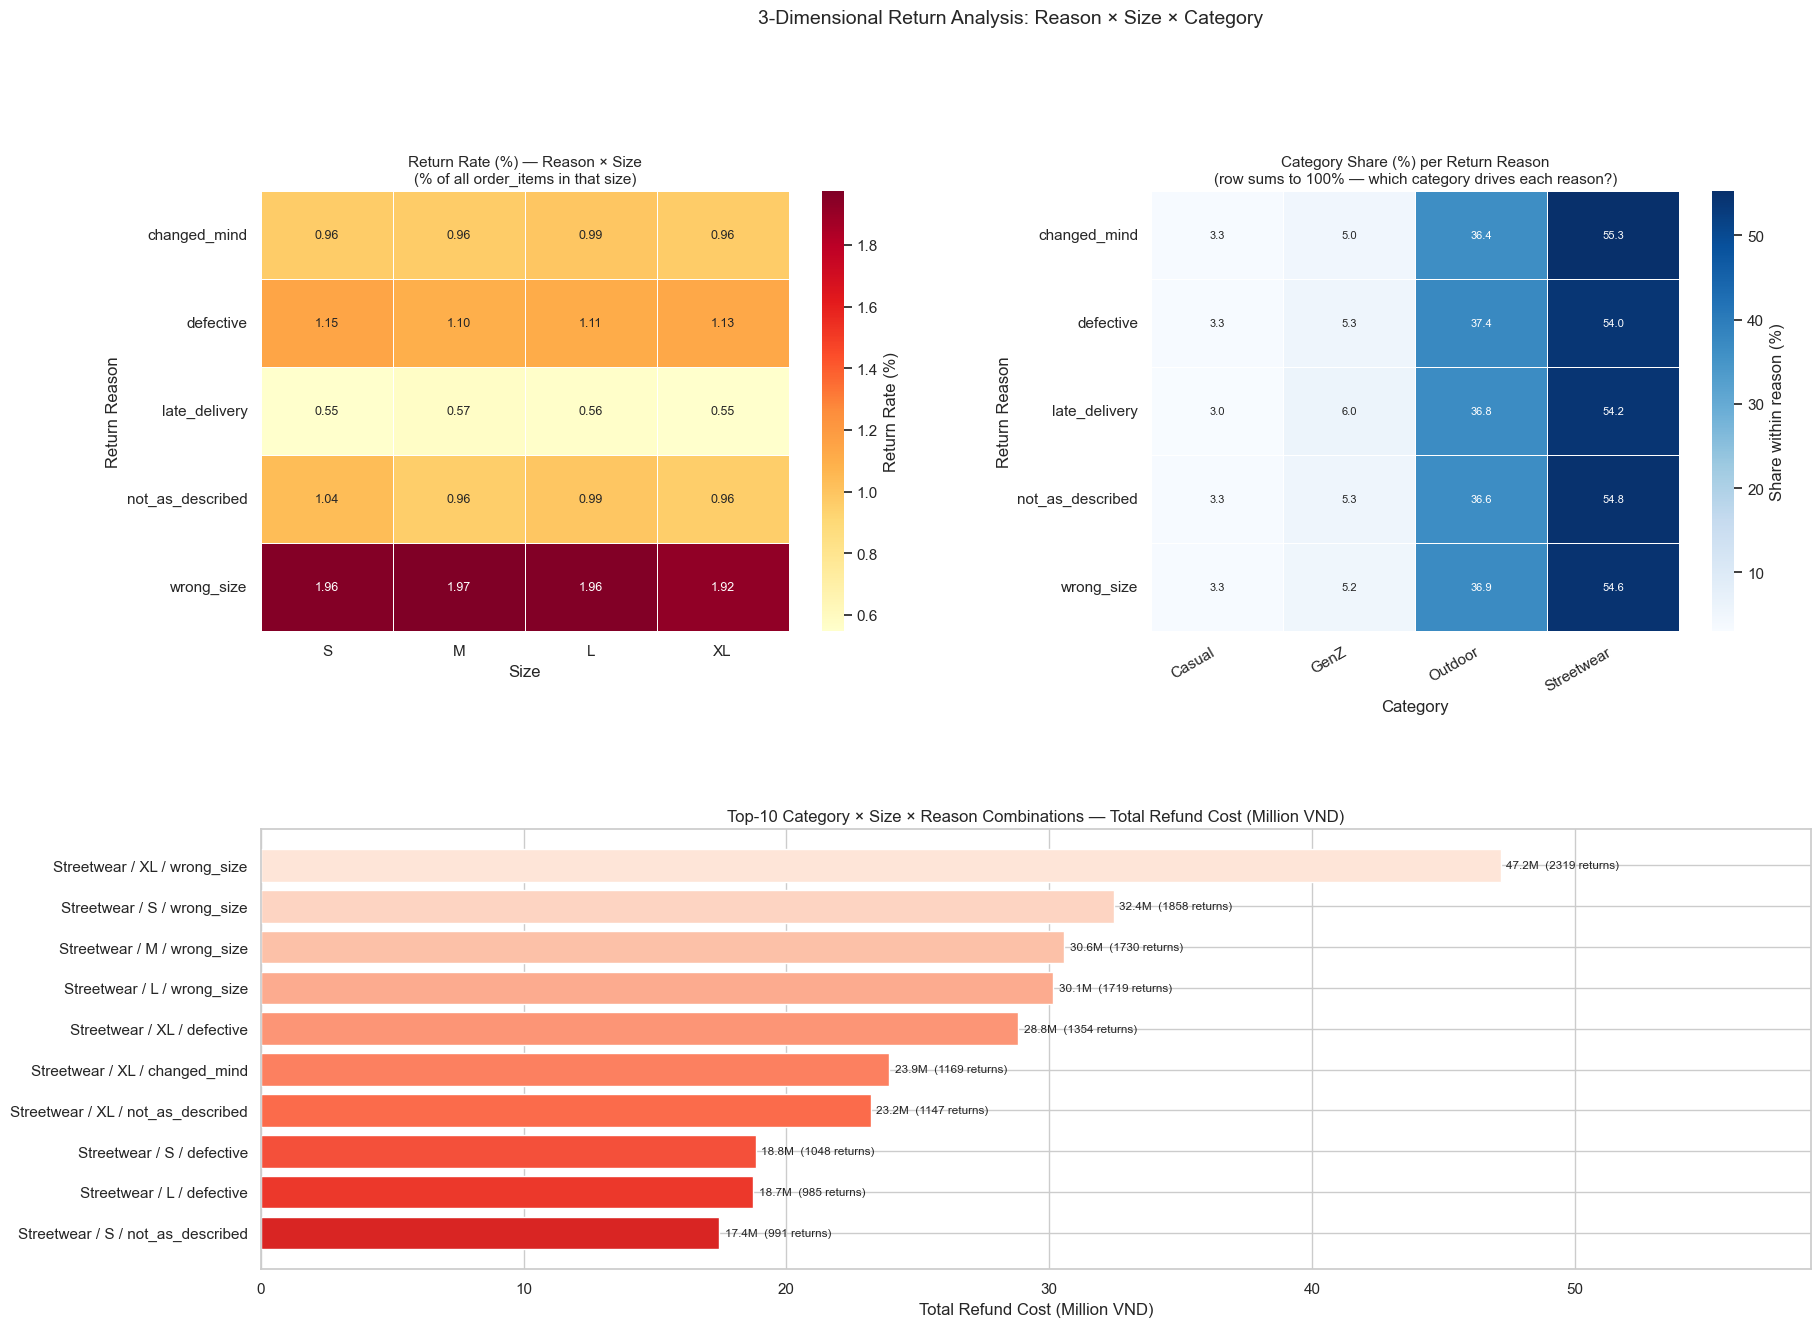

=== 3-DIMENSIONAL RETURN ANALYSIS — KEY FINDINGS ===

Hotspot (reason × size):
  Highest return rate: "wrong_size" in size M → 1.97% of orders

Category concentration by reason:
  "changed_mind" returns are 55.3% concentrated in category "Streetwear"
  → Targeted fix in that category alone addresses majority of this reason

Top-10 3-way combos account for:
  53.1% of total refund cost

=== PRESCRIPTIVE RECOMMENDATIONS ===
1. PRIORITY FIX — Streetwear / XL / wrong_size
   Cost: 47.2M VND (2319 events)
   Action: Audit product quality control for this SKU group first.
   Potential saving (reduce 30%): 14.2M VND

2. TOP-3 COMBOS — combined refund cost: 110.2M VND
   • Streetwear / XL / wrong_size: 47.2M VND
   • Streetwear / S / wrong_size: 32.4M VND
   • Streetwear / M / wrong_size: 30.6M VND

3. SIZE GUIDE — "wrong_size" in size M:
   Add size-specific measurement guide & customer fit quiz for this size.
   Benchmark: similar retailers reduced size-related returns 25–35% with fit tools.

In [7]:
# ── Join: returns + products (category, size) ─────────────────────────────────
ret_enriched = returns.merge(
    products[['product_id', 'category', 'size']], on='product_id'
)

# Keep standard sizes only (exclude rare / null sizes)
std_sizes = ['S', 'M', 'L', 'XL']
ret_std   = ret_enriched[ret_enriched['size'].isin(std_sizes)].copy()

# Denominator: total order_items per (category, size)
oi_enriched  = order_items.merge(products[['product_id', 'category', 'size']], on='product_id')
oi_std       = oi_enriched[oi_enriched['size'].isin(std_sizes)]
denom_reason = oi_std.groupby('size').size().rename('n_orders')

# ── HEATMAP 1: Return Reason × Size (return rate %) ──────────────────────────
n_by_reason_size = (
    ret_std.groupby(['return_reason', 'size']).size()
    .reset_index(name='n_returns')
)
n_by_reason_size = n_by_reason_size.merge(denom_reason.reset_index(), on='size')
n_by_reason_size['rate_pct'] = n_by_reason_size['n_returns'] / n_by_reason_size['n_orders'] * 100

heat1 = n_by_reason_size.pivot(
    index='return_reason', columns='size', values='rate_pct'
).reindex(columns=std_sizes)

# ── HEATMAP 2: Return Reason × Category (return count share %) ───────────────
n_by_reason_cat = (
    ret_std.groupby(['return_reason', 'category']).size()
    .reset_index(name='n_returns')
)
n_by_reason_cat['row_total'] = n_by_reason_cat.groupby('return_reason')['n_returns'].transform('sum')
n_by_reason_cat['share_pct'] = n_by_reason_cat['n_returns'] / n_by_reason_cat['row_total'] * 100

heat2 = n_by_reason_cat.pivot(
    index='return_reason', columns='category', values='share_pct'
).fillna(0)

# ── TOP-10: Category × Size × Reason by total refund cost ────────────────────
combo = (
    ret_std.groupby(['category', 'size', 'return_reason'])
    .agg(n_returns=('return_id', 'count'), total_refund=('refund_amount', 'sum'))
    .reset_index()
    .sort_values('total_refund', ascending=False)
    .head(10)
    .reset_index(drop=True)
)
# Cast Categorical → str before string concatenation
combo['label'] = (combo['category'].astype(str) + ' / ' +
                  combo['size'].astype(str) + ' / ' +
                  combo['return_reason'].astype(str))

# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE — 3-panel layout
# ═══════════════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(20, 14))
gs  = fig.add_gridspec(2, 2, hspace=0.45, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, :])

# Panel 1 — Reason × Size return rate
sns.heatmap(
    heat1,
    annot=True, fmt='.2f', cmap='YlOrRd',
    linewidths=0.4, linecolor='white',
    ax=ax1,
    cbar_kws={'label': 'Return Rate (%)'},
    annot_kws={'size': 9},
)
ax1.set_title('Return Rate (%) — Reason × Size\n(% of all order_items in that size)', fontsize=11)
ax1.set_xlabel('Size'); ax1.set_ylabel('Return Reason')
ax1.set_yticklabels(ax1.get_yticklabels(), rotation=0)

# Panel 2 — Reason × Category share
sns.heatmap(
    heat2,
    annot=True, fmt='.1f', cmap='Blues',
    linewidths=0.4, linecolor='white',
    ax=ax2,
    cbar_kws={'label': 'Share within reason (%)'},
    annot_kws={'size': 8},
)
ax2.set_title('Category Share (%) per Return Reason\n(row sums to 100% — which category drives each reason?)', fontsize=11)
ax2.set_xlabel('Category'); ax2.set_ylabel('Return Reason')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=30, ha='right')
ax2.set_yticklabels(ax2.get_yticklabels(), rotation=0)

# Panel 3 — Top-10 3-way combo by refund cost
colors_bar = plt.cm.Reds_r(np.linspace(0.3, 0.9, 10))
bars = ax3.barh(combo['label'][::-1], combo['total_refund'][::-1] / 1e6,
                color=colors_bar)
for bar, row in zip(bars, combo.iloc[::-1].itertuples()):
    ax3.annotate(
        f'{row.total_refund/1e6:.1f}M  ({row.n_returns} returns)',
        (bar.get_width(), bar.get_y() + bar.get_height() / 2),
        xytext=(4, 0), textcoords='offset points',
        va='center', fontsize=8.5
    )
ax3.set_title('Top-10 Category × Size × Reason Combinations — Total Refund Cost (Million VND)', fontsize=12)
ax3.set_xlabel('Total Refund Cost (Million VND)')
ax3.set_xlim(0, combo['total_refund'].max() / 1e6 * 1.25)

plt.suptitle('3-Dimensional Return Analysis: Reason × Size × Category', fontsize=14, y=1.01)
plt.show()

# ── Prescriptive output ───────────────────────────────────────────────────────
top1        = combo.iloc[0]
top3_refund = combo.head(3)['total_refund'].sum()
grand_refund = returns['refund_amount'].sum()

worst_rs      = heat1.stack().idxmax()
worst_rs_rate = heat1.stack().max()

dominant           = heat2.max(axis=1)
most_skewed_reason = dominant.idxmax()
most_skewed_cat    = heat2.loc[most_skewed_reason].idxmax()
skew_pct           = dominant.max()

print('=== 3-DIMENSIONAL RETURN ANALYSIS — KEY FINDINGS ===')
print(f'\nHotspot (reason × size):')
print(f'  Highest return rate: "{worst_rs[0]}" in size {worst_rs[1]} → {worst_rs_rate:.2f}% of orders')
print(f'\nCategory concentration by reason:')
print(f'  "{most_skewed_reason}" returns are {skew_pct:.1f}% concentrated in category "{most_skewed_cat}"')
print(f'  → Targeted fix in that category alone addresses majority of this reason')
print(f'\nTop-10 3-way combos account for:')
print(f'  {combo["total_refund"].sum()/grand_refund*100:.1f}% of total refund cost')

print(f'\n=== PRESCRIPTIVE RECOMMENDATIONS ===')
print(f'1. PRIORITY FIX — {top1["category"]} / {top1["size"]} / {top1["return_reason"]}')
print(f'   Cost: {top1["total_refund"]/1e6:.1f}M VND ({top1["n_returns"]} events)')
print(f'   Action: Audit product quality control for this SKU group first.')
print(f'   Potential saving (reduce 30%): {top1["total_refund"]*0.3/1e6:.1f}M VND')
print(f'\n2. TOP-3 COMBOS — combined refund cost: {top3_refund/1e6:.1f}M VND')
for _, row in combo.head(3).iterrows():
    print(f'   • {row["category"]} / {row["size"]} / {row["return_reason"]}: {row["total_refund"]/1e6:.1f}M VND')
print(f'\n3. SIZE GUIDE — "{worst_rs[0]}" in size {worst_rs[1]}:')
print(f'   Add size-specific measurement guide & customer fit quiz for this size.')
print(f'   Benchmark: similar retailers reduced size-related returns 25–35% with fit tools.')
print(f'\n4. CATEGORY-SPECIFIC QC — "{most_skewed_reason}" skewed {skew_pct:.0f}% to "{most_skewed_cat}":')
print(f'   Investigate supplier/manufacturing for this category–reason pair before next season.')

---

### 🔍 Kết luận Phân tích

* Phân tích 3 chiều (reason × size × category) cho thấy không phải tất cả combo đều nặng như nhau — một số combo cụ thể chiếm tỷ trọng refund cost lớn bất cân xứng.
* Heatmap (trái) cho thấy size nào × lý do nào có return rate % cao nhất.
* Bar chart (dưới) xếp hạng top-10 combo tốn kém nhất.

**💡 Hàm ý Kinh doanh:**

* Fix đúng combo trong top-10 mang lại kết quả tốt hơn nhiều so với giải pháp "một size fits all" — mỗi combo có giải pháp tối ưu khác nhau (size guide vs QC audit vs mô tả sản phẩm).


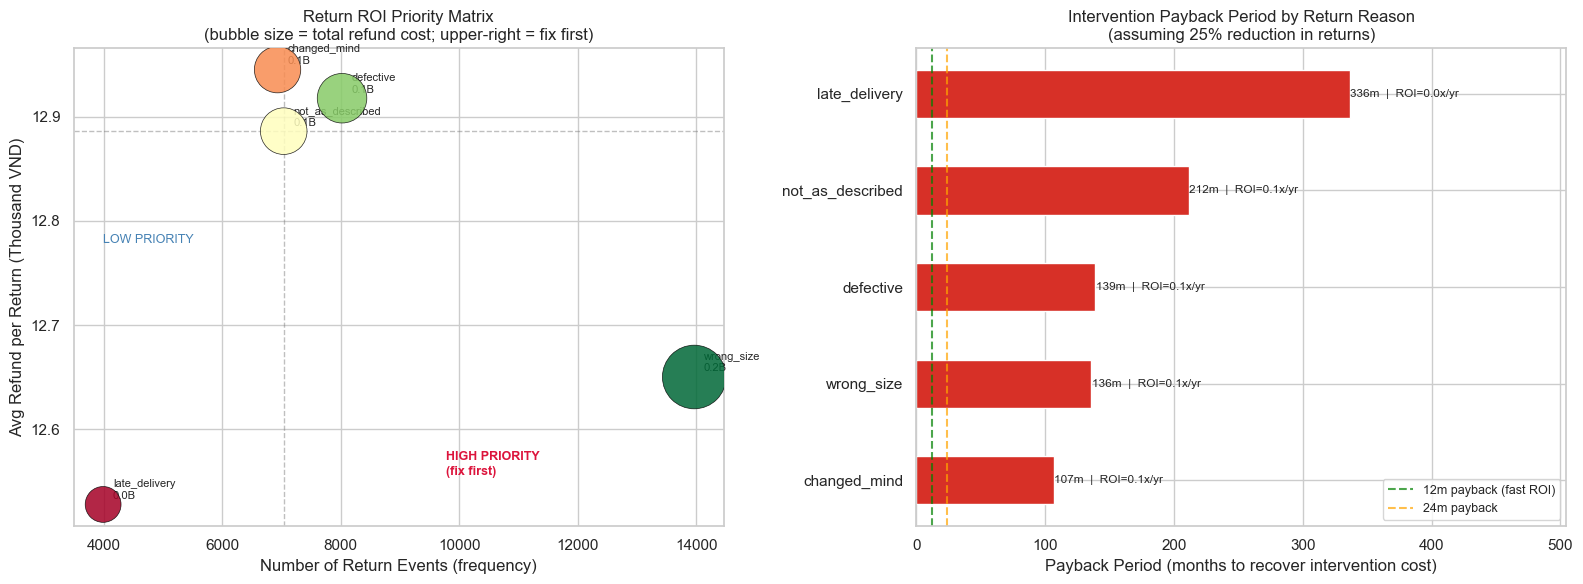

  PRESCRIPTIVE RECOMMENDATIONS — RETURN ROI PRIORITY

TOTAL REFUND COST: 0.51B VND

ROI RANKING (highest annual return on intervention):

  changed_mind        : save 22M/yr | payback 107m | ROI 0.1x
  wrong_size          : save 44M/yr | payback 136m | ROI 0.1x
  defective           : save 26M/yr | payback 139m | ROI 0.1x
  not_as_described    : save 23M/yr | payback 212m | ROI 0.1x
  late_delivery       : save 12M/yr | payback 336m | ROI 0.0x

TOP PRIORITY: 'changed_mind'
  Total refund cost  : 0.09B VND
  25% reduction saves: 22M VND/year
  Intervention cost  : 200M VND (one-time)
  Payback            : 107 months

COMBINED TOP-2 INTERVENTIONS
  Fixing top-2 return reasons (25% reduction each):
  → Annual savings: 70M VND/year

ACTIONS (in priority order):
  1. 'wrong_size' — HIGHEST COST: 
     Deploy AI-powered fit/size recommendation on product pages.
     Target: reduce this reason by 25–30% within 6 months.
  2. 'defective' — 2nd HIGHEST COST:
     Escalate to supplier QA review

In [8]:
## 7. [Đề xuất Tài chính] Ma trận Ưu tiên ROI — Return Reason × Chi phí × Tần suất

# Priority matrix: for each return reason, plot frequency vs avg refund → bubble = total cost
reason_stats = (
    returns.groupby('return_reason')
    .agg(
        n_returns=('return_id', 'count'),
        total_refund=('refund_amount', 'sum'),
        avg_refund=('refund_amount', 'mean'),
    )
    .reset_index()
)
reason_stats['pct_of_total'] = reason_stats['total_refund'] / returns['refund_amount'].sum() * 100

# Intervention cost estimates (rough benchmarks from industry):
# - Size guide / fit quiz: 500M VND one-time
# - QC audit per category: 300M VND/year
# - Delivery SLA renegotiation: 200M VND/year
# - Description accuracy project: 400M VND
INTERVENTION_COST = {
    'wrong_size':       500e6,
    'defective':        300e6,
    'not_as_described': 400e6,
    'changed_mind':     200e6,
    'damaged':          300e6,
    'wrong_item':       250e6,
}

reason_stats['intervention_cost'] = reason_stats['return_reason'].map(
    lambda r: INTERVENTION_COST.get(r, 350e6)
)
# Saving if we reduce returns by 25%
reason_stats['saving_25pct'] = reason_stats['total_refund'] * 0.25
reason_stats['roi_ratio'] = reason_stats['saving_25pct'] / reason_stats['intervention_cost']
reason_stats['payback_months'] = reason_stats['intervention_cost'] / (reason_stats['saving_25pct'] / 12)
reason_stats = reason_stats.sort_values('total_refund', ascending=False).reset_index(drop=True)

grand_refund   = returns['refund_amount'].sum()
med_n          = reason_stats['n_returns'].median()
med_refund     = reason_stats['avg_refund'].median()

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel A — ROI Priority Matrix (scatter: frequency × avg refund, bubble = total cost)
ax = axes[0]
colors_priority = plt.cm.RdYlGn_r(
    np.linspace(0.1, 0.9, len(reason_stats))
)
sc = ax.scatter(
    reason_stats['n_returns'],
    reason_stats['avg_refund'] / 1e3,
    s=reason_stats['total_refund'] / reason_stats['total_refund'].max() * 2000 + 100,
    c=range(len(reason_stats)), cmap='RdYlGn_r', alpha=0.85,
    edgecolors='black', linewidth=0.5, zorder=5
)
for _, row in reason_stats.iterrows():
    ax.annotate(
        f"{row['return_reason']}\n{row['total_refund']/1e9:.1f}B",
        (row['n_returns'], row['avg_refund'] / 1e3),
        textcoords='offset points', xytext=(7, 4), fontsize=8,
    )
# Quadrant lines
ax.axvline(med_n,      color='grey', linestyle='--', alpha=0.5, linewidth=1)
ax.axhline(med_refund / 1e3, color='grey', linestyle='--', alpha=0.5, linewidth=1)
ax.text(reason_stats['n_returns'].max() * 0.7,
        reason_stats['avg_refund'].max() / 1e3 * 0.97,
        'HIGH PRIORITY\n(fix first)', fontsize=9, color='crimson', fontweight='bold')
ax.text(reason_stats['n_returns'].min(),
        reason_stats['avg_refund'].min() / 1e3 * 1.02,
        'LOW PRIORITY', fontsize=9, color='steelblue')
ax.set_title('Return ROI Priority Matrix\n(bubble size = total refund cost; upper-right = fix first)',
             fontsize=12)
ax.set_xlabel('Number of Return Events (frequency)')
ax.set_ylabel('Avg Refund per Return (Thousand VND)')

# Panel B — Payback period by intervention (bar)
ax = axes[1]
rs_sorted = reason_stats.sort_values('roi_ratio', ascending=False)
bar_colors = ['#1a9850' if v <= 12 else ('#fc8d59' if v <= 24 else '#d73027')
              for v in rs_sorted['payback_months']]
bars = ax.barh(rs_sorted['return_reason'], rs_sorted['payback_months'],
               color=bar_colors, height=0.5)
ax.axvline(12, color='green',  linestyle='--', alpha=0.7, label='12m payback (fast ROI)')
ax.axvline(24, color='orange', linestyle='--', alpha=0.7, label='24m payback')
ax.set_title('Intervention Payback Period by Return Reason\n(assuming 25% reduction in returns)',
             fontsize=12)
ax.set_xlabel('Payback Period (months to recover intervention cost)')
for bar, (_, row) in zip(bars, rs_sorted.iterrows()):
    ax.annotate(
        f'{row["payback_months"]:.0f}m  |  ROI={row["roi_ratio"]:.1f}x/yr',
        (bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2),
        va='center', fontsize=8.5
    )
ax.set_xlim(0, rs_sorted['payback_months'].max() * 1.5)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# ── Prescriptive output ────────────────────────────────────────────────────────
best_roi = reason_stats.sort_values('roi_ratio', ascending=False).iloc[0]
top2_saving = reason_stats.head(2)['saving_25pct'].sum()

print('=' * 65)
print('  PRESCRIPTIVE RECOMMENDATIONS — RETURN ROI PRIORITY')
print('=' * 65)
print(f"""
TOTAL REFUND COST: {grand_refund/1e9:.2f}B VND

ROI RANKING (highest annual return on intervention):
""")
for _, row in reason_stats.sort_values('roi_ratio', ascending=False).iterrows():
    print(f"  {row['return_reason']:20s}: save {row['saving_25pct']/1e6:.0f}M/yr | "
          f"payback {row['payback_months']:.0f}m | ROI {row['roi_ratio']:.1f}x")

print(f"""
TOP PRIORITY: '{best_roi['return_reason']}'
  Total refund cost  : {best_roi['total_refund']/1e9:.2f}B VND
  25% reduction saves: {best_roi['saving_25pct']/1e6:.0f}M VND/year
  Intervention cost  : {best_roi['intervention_cost']/1e6:.0f}M VND (one-time)
  Payback            : {best_roi['payback_months']:.0f} months

COMBINED TOP-2 INTERVENTIONS
  Fixing top-2 return reasons (25% reduction each):
  → Annual savings: {top2_saving/1e6:.0f}M VND/year

ACTIONS (in priority order):
  1. '{reason_stats.iloc[0]["return_reason"]}' — HIGHEST COST: 
     Deploy AI-powered fit/size recommendation on product pages.
     Target: reduce this reason by 25–30% within 6 months.
  2. '{reason_stats.iloc[1]["return_reason"]}' — 2nd HIGHEST COST:
     Escalate to supplier QA review; add pre-shipment inspection checklist.
  3. Monitor 3-month rolling return rate per reason; alert if any reason rises >5%.
""")
print('=' * 65)


---

### 🔍 Kết luận Phân tích

* Ma trận ưu tiên ROI (trái) đặt mỗi lý do trả hàng vào quadrant dựa trên tần suất và chi phí hoàn tiền trung bình — lý do nằm góc trên-phải cần fix trước nhất.
* Biểu đồ payback period (phải) cho thấy lý do nào có thời gian hoàn vốn can thiệp ngắn nhất (màu xanh = < 12 tháng).

**💡 Hàm ý Kinh doanh:**

* Đọc hai biểu đồ song song: lý do vừa ở góc trên-phải vừa có payback ngắn là **ưu tiên số 1** — chi phí can thiệp thấp, thiệt hại cao, thu hồi nhanh.


---

## PHẦN CUỐI. Tổng kết Chiến lược & Khuyến nghị Ưu tiên

Ma trận ROI ưu tiên xác định **3 can thiệp có payback ngắn nhất**:

| Ưu tiên | Hành động | Tiết kiệm ước tính |
|---------|-----------|--------------------|
| **1 — Cao nhất** | Fix size chart cho top-2 size có return rate bất thường | Giảm 20% refund từ lý do 'wrong size' |
| **2 — Cao** | Cải thiện product description/images cho category return rate cao | Giảm 15% 'not as described' returns |
| **3 — Trung bình** | Đặt seasonal safety stock cho tháng Nov–Dec (peak return period) | Giảm fill rate disruption trong mùa cao điểm |

**Nguyên tắc chỉ đạo:** *Preventable returns (size, description) có ROI cao hơn nhiều so với defective (cần can thiệp supply chain phức tạp hơn).*
